In [ ]:
#@title 0) setup

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset




# 1) Build the Dataset of (A+B % 5)

With A and B in the range of 0..99

In [ ]:
dataset = []

for a in range(100):
    for b in range(100):
        result = (a + b) % 5
        dataset.append((a, b, result))

In [ ]:
#@title Sanity check


# Quick sanity checks
print(f"Dataset size: {len(dataset)}")
print()
print("First 12 samples:")
for a, b, r in dataset[:12]:
    print(f"  A={a:2d}  B={b:2d}  →  ({a}+{b}) % 5 = {r}")

# Output class balance
from collections import Counter
counts = Counter(r for _, _, r in dataset)
print(f"\nClass distribution: {dict(sorted(counts.items()))}")
print("(perfectly balanced — as all things should be)")


Dataset size: 10000

First 12 samples:
  A= 0  B= 0  →  (0+0) % 5 = 0
  A= 0  B= 1  →  (0+1) % 5 = 1
  A= 0  B= 2  →  (0+2) % 5 = 2
  A= 0  B= 3  →  (0+3) % 5 = 3
  A= 0  B= 4  →  (0+4) % 5 = 4
  A= 0  B= 5  →  (0+5) % 5 = 0
  A= 0  B= 6  →  (0+6) % 5 = 1
  A= 0  B= 7  →  (0+7) % 5 = 2
  A= 0  B= 8  →  (0+8) % 5 = 3
  A= 0  B= 9  →  (0+9) % 5 = 4
  A= 0  B=10  →  (0+10) % 5 = 0
  A= 0  B=11  →  (0+11) % 5 = 1

Class distribution: {0: 2000, 1: 2000, 2: 2000, 3: 2000, 4: 2000}
(perfectly balanced — as all things should be)


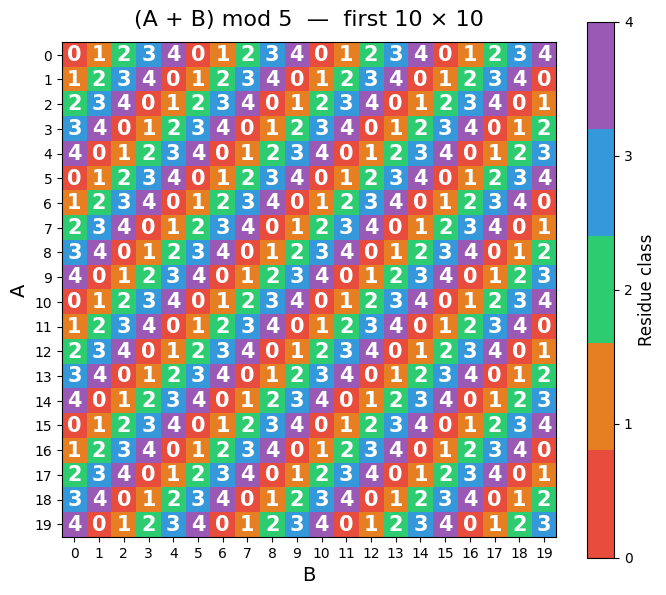

Notice the diagonal stripes — that's the structure the network must learn!


In [ ]:
#@title 🎨 Mod-5 Color Grid — click ▶ to reveal { display-mode: "form" }

# Build a 10×10 preview grid
grid = np.zeros((20, 20), dtype=int)
for a in range(20):
    for b in range(20):
        grid[a][b] = (a + b) % 5

# Pretty colors for each residue class
palette = ["#e74c3c", "#e67e22", "#2ecc71", "#3498db", "#9b59b6"]
cmap = mcolors.ListedColormap(palette)

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=4)

# Label every cell
for a in range(20):
    for b in range(20):
        ax.text(b, a, str(grid[a][b]),
                ha="center", va="center",
                fontsize=15, fontweight="bold", color="white")

ax.set_xticks(range(20))
ax.set_yticks(range(20))
ax.set_xlabel("B", fontsize=14)
ax.set_ylabel("A", fontsize=14)
ax.set_title("(A + B) mod 5  —  first 10 × 10", fontsize=16, pad=12)

cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3, 4], shrink=0.8)
cbar.set_label("Residue class", fontsize=12)

plt.tight_layout()
plt.show()
print("Notice the diagonal stripes — that's the structure the network must learn!")


# 2) PyTorch MLP

**Input:** 200-dim one-hot (100 for A ⊕ 100 for B)  
**Output:** 5 classes (residues 0–4)  
**Hidden layers:** 32 → ReLU → 16 → ReLU  

Parameter budget: 7,045 — that's **70 %** of the 10,000-sample dataset,
so the network can't just memorize everything.

In [ ]:
class Mod5MLP(nn.Module):
    def __init__(self, hidden1=32, hidden2=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(200, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 5),
        )
        # Parameter count (for default 32/16):
        #   200×32+32 = 6432
        #   32×16+16 =  528
        #   16× 5+ 5 =   85
        #               ────
        #               7045
        # (70.4 % of 10,000 dataset)
        # (i.e. model can't memorize this dataset)

    def forward(self, x):
        return self.net(x)

model = Mod5MLP()
print(model)

Mod5MLP(
  (net): Sequential(
    (0): Linear(in_features=200, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=5, bias=True)
  )
)


# 3) Train / Val Split (70 / 30)

In [ ]:
class Mod5Dataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        a, b, result = self.data[idx]
        # One-hot: first 100 dims = A, next 100 dims = B
        x = torch.zeros(200)
        x[a] = 1.0
        x[100 + b] = 1.0
        return x, result

In [ ]:
full_dataset = Mod5Dataset(dataset)

indices = list(range(len(full_dataset)))

train_indices, validation_indices = train_test_split(
    indices,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

train_dataset = Subset(full_dataset, train_indices)
val_dataset = Subset(full_dataset, validation_indices)

print(f"Train : {len(train_dataset):,}")
print(f"validation   : {len(val_dataset):,}")

Train : 7,000
validation   : 3,000


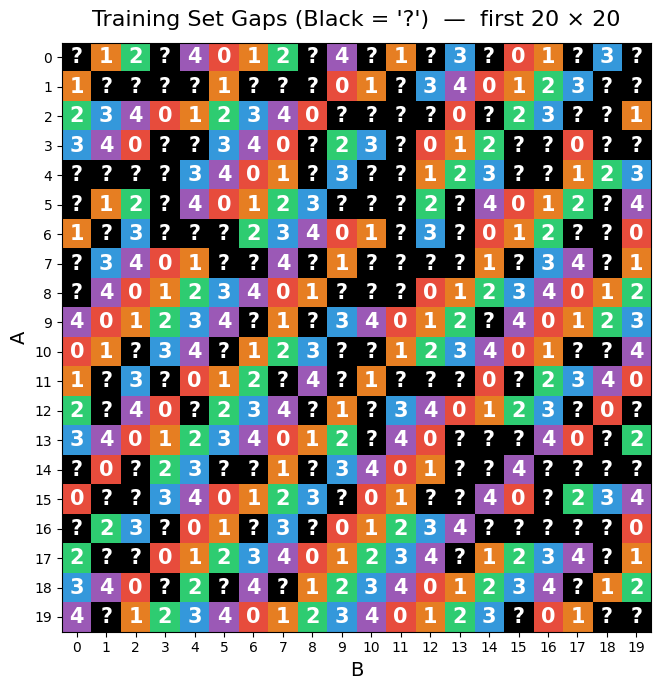

In [ ]:
#@title Visualize training set gaps
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Convert train_indices to a set for fast lookup
train_set = set(train_indices)

grid_size = 20
grid = np.zeros((grid_size, grid_size), dtype=int)
is_train = np.zeros((grid_size, grid_size), dtype=bool)

for a in range(grid_size):
    for b in range(grid_size):
        # Calculate the original flat index in the 100x100 dataset
        idx = a * 100 + b
        if idx in train_set:
            grid[a][b] = (a + b) % 5
            is_train[a][b] = True
        else:
            grid[a][b] = -1  # -1 represents missing/val data

# Add black (#000000) at the beginning of the palette for the -1 class
palette = ["#000000", "#e74c3c", "#e67e22", "#2ecc71", "#3498db", "#9b59b6"]
cmap = mcolors.ListedColormap(palette)

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(grid, cmap=cmap, vmin=-1, vmax=4)

for a in range(grid_size):
    for b in range(grid_size):
        text = str((a + b) % 5) if is_train[a][b] else "?"
        ax.text(b, a, text,
                ha="center", va="center",
                fontsize=15, fontweight="bold", color="white")

ax.set_xticks(range(grid_size))
ax.set_yticks(range(grid_size))
ax.set_xlabel("B", fontsize=14)
ax.set_ylabel("A", fontsize=14)
ax.set_title("Training Set Gaps (Black = '?')  —  first 20 × 20", fontsize=16, pad=12)

plt.tight_layout()
plt.show()

# 4) Training Loop

Bare-bones: **AdamW**, **CrossEntropyLoss**, batch size 32, hardcoded LR.  
Stops at 50 epochs or 100 % val accuracy — whichever comes first.

In [ ]:
def calculate_accuracy(model, dataloader):
    """Fraction of correct predictions (0.0 – 1.0)."""
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in dataloader:
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

In [ ]:
def train_model(model, train_ds, val_ds, lr=1e-3, batch_size=32, max_epochs=50):
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"epoch": [], "loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        for x, y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss  = running_loss / len(train_loader)
        train_acc = calculate_accuracy(model, train_loader)
        val_acc   = calculate_accuracy(model, val_loader)

        history["epoch"].append(epoch)
        history["loss"].append(avg_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        #if epoch % 20 == 0 or val_acc == 1.0:
        print(f"Epoch {epoch:3d}  │  Loss {avg_loss:.4f}  │  "
              f"Train {train_acc:.1%}  │  Val {val_acc:.1%}")

        if val_acc == 1.0:
            print(f"\n✅  Perfect val accuracy at epoch {epoch}!")
            break

    return history

In [ ]:
# ── Run it ────────────────────────────────────────────────────
model = Mod5MLP()
history = train_model(model, train_dataset, val_dataset, lr=1e-3, batch_size=32)

Epoch   1  │  Loss 1.6118  │  Train 20.2%  │  Val 19.6%
Epoch   2  │  Loss 1.6090  │  Train 26.9%  │  Val 20.4%
Epoch   3  │  Loss 1.5923  │  Train 50.0%  │  Val 40.8%
Epoch   4  │  Loss 1.3009  │  Train 88.4%  │  Val 85.3%
Epoch   5  │  Loss 0.5677  │  Train 100.0%  │  Val 99.9%
Epoch   6  │  Loss 0.1767  │  Train 100.0%  │  Val 100.0%

✅  Perfect val accuracy at epoch 6!


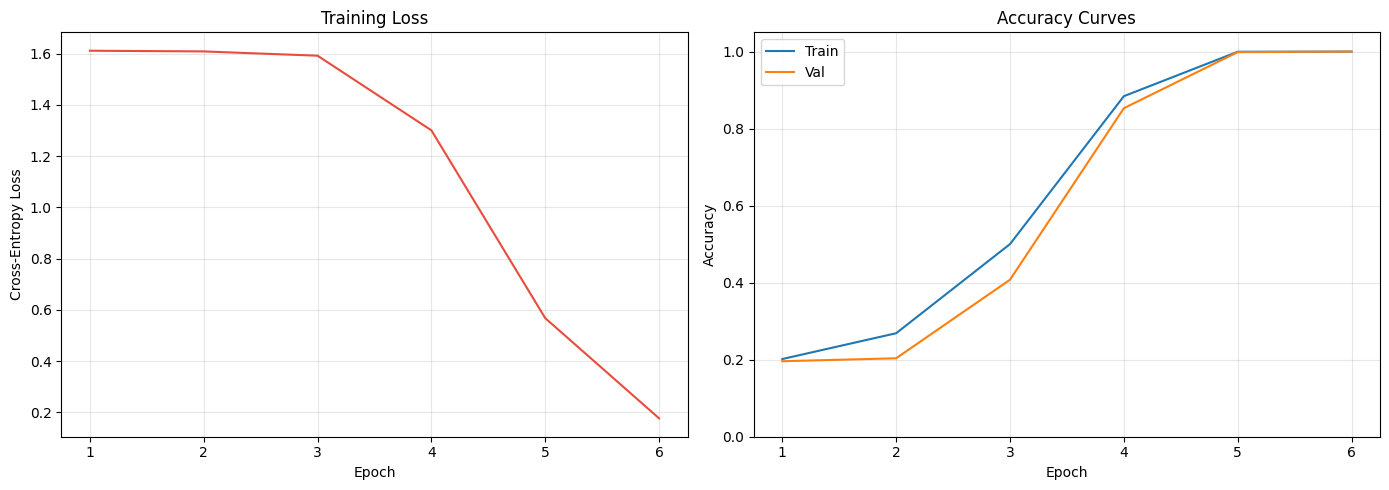

In [ ]:
#@title Visualize training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(history["epoch"], history["loss"], color="#e74c3c", linewidth=1.5)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.set_title("Training Loss")
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(history["epoch"], history["train_acc"], label="Train", linewidth=1.5)
ax2.plot(history["epoch"], history["val_acc"],   label="Val",   linewidth=1.5)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy Curves")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


# 5) Learning-Rate Sweep

Train a **fresh** model for each LR and record how many epochs it takes
to hit 100 % val accuracy (capped at 25).

In [ ]:
def epochs_to_converge(lr, batch_size=32, max_epochs=25, hidden1=32, hidden2=16):
    """Train a fresh Mod5MLP; return #epochs to 100% val acc (or max_epochs)."""
    print(f"\nStarting run with LR = {lr:.0e}, bs={batch_size}, h1={hidden1}, h2={hidden2}")
    mdl = Mod5MLP(hidden1=hidden1, hidden2=hidden2)
    history = train_model(mdl, train_dataset, val_dataset, lr=lr, batch_size=batch_size, max_epochs=max_epochs)

    if history["val_acc"][-1] == 1.0:
        return history["epoch"][-1]
    print("Model did not converge")
    return max_epochs

In [ ]:
# Ten LRs spanning "way too small" to "way too big"
learning_rates = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1]

lr_results = {}
for lr in learning_rates:
    ep = epochs_to_converge(lr)
    lr_results[lr] = ep
    tag = f"{ep} epochs" if ep < 500 else "DID NOT CONVERGE"
    print(f"  LR = {lr:.0e}  →  {tag}")


Starting run with LR = 1e-05, bs=32, h1=32, h2=16
Epoch   1  │  Loss 1.6118  │  Train 19.9%  │  Val 20.4%
Epoch   2  │  Loss 1.6117  │  Train 20.0%  │  Val 20.3%
Epoch   3  │  Loss 1.6116  │  Train 19.9%  │  Val 20.3%
Epoch   4  │  Loss 1.6115  │  Train 20.0%  │  Val 20.3%
Epoch   5  │  Loss 1.6115  │  Train 19.9%  │  Val 20.4%
Epoch   6  │  Loss 1.6114  │  Train 20.0%  │  Val 20.4%
Epoch   7  │  Loss 1.6113  │  Train 20.0%  │  Val 20.4%
Epoch   8  │  Loss 1.6112  │  Train 20.2%  │  Val 20.4%
Epoch   9  │  Loss 1.6112  │  Train 20.2%  │  Val 20.4%
Epoch  10  │  Loss 1.6111  │  Train 20.2%  │  Val 20.3%
Epoch  11  │  Loss 1.6110  │  Train 20.2%  │  Val 20.3%
Epoch  12  │  Loss 1.6109  │  Train 20.3%  │  Val 20.3%
Epoch  13  │  Loss 1.6109  │  Train 20.3%  │  Val 20.3%
Epoch  14  │  Loss 1.6108  │  Train 20.4%  │  Val 20.1%
Epoch  15  │  Loss 1.6107  │  Train 20.4%  │  Val 20.1%
Epoch  16  │  Loss 1.6107  │  Train 20.4%  │  Val 20.0%
Epoch  17  │  Loss 1.6106  │  Train 20.5%  │  Val 19.

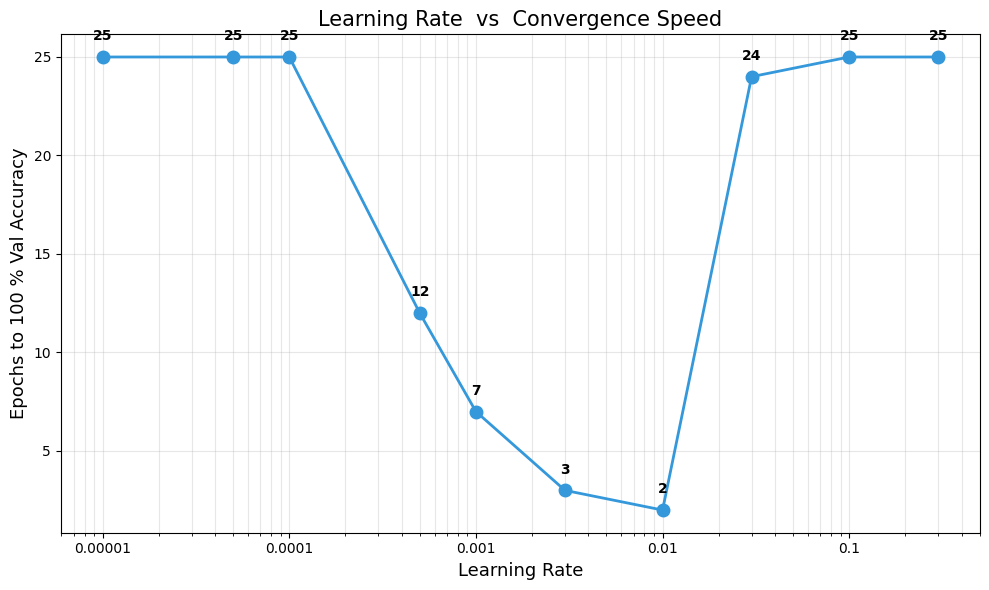

In [ ]:
#@title Visualize LRs
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 6))

lrs    = list(lr_results.keys())
epochs = list(lr_results.values())

ax.plot(lrs, epochs, "o-", markersize=9, linewidth=2, color="#3498db")
ax.set_xscale("log")
# Format x-axis to avoid scientific notation
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:.5f}".rstrip('0').rstrip('.')))

ax.set_xlabel("Learning Rate", fontsize=13)
ax.set_ylabel("Epochs to 100 % Val Accuracy", fontsize=13)
ax.set_title("Learning Rate  vs  Convergence Speed", fontsize=15)
ax.grid(True, alpha=0.3, which="both")

for lr_val, ep in zip(lrs, epochs):
    label = str(ep) if ep < 500 else "✗"
    ax.annotate(label, (lr_val, ep), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

# 6) Exercise: Batch-Size Sweep

Same idea, but now we fix the LR and vary batch size.

In [ ]:
batch_sizes = [4, 8, 16, 32, 64, 128, 256, 512, 1024, 2000]

# Find the best batch size.
# call epochs_to_converge with the best LR from section 5 and the batch sizes above.
assert False, "todo: invoke epochs_to_converge in a for loop"

AssertionError: todo: invoke epochs_to_converge in a for loop

In [ ]:
#@title  answer
batch_sizes = [4, 8, 16, 32, 64, 128, 256, 512, 1024, 2000]

bs_results = {}
for bs in batch_sizes:
    ep = epochs_to_converge(lr=1e-3, batch_size=bs)
    bs_results[bs] = ep
    tag = f"{ep} epochs" if ep < 25 else "DID NOT CONVERGE"
    print(f"  Batch size = {bs:>4d}  →  {tag}")



Starting run with LR = 0.00100
Epoch   1  │  Loss 1.6119  │  Train 27.0%  │  Val 24.1%
Epoch   2  │  Loss 1.1645  │  Train 99.7%  │  Val 99.5%
Epoch   3  │  Loss 0.1074  │  Train 100.0%  │  Val 100.0%

✅  Perfect val accuracy at epoch 3!
  Batch size =    4  →  3 epochs

Starting run with LR = 0.00100
Epoch   1  │  Loss 1.6130  │  Train 20.3%  │  Val 19.4%
Epoch   2  │  Loss 1.5555  │  Train 53.6%  │  Val 50.7%
Epoch   3  │  Loss 0.7980  │  Train 99.9%  │  Val 99.9%
Epoch   4  │  Loss 0.1139  │  Train 100.0%  │  Val 100.0%

✅  Perfect val accuracy at epoch 4!
  Batch size =    8  →  4 epochs

Starting run with LR = 0.00100
Epoch   1  │  Loss 1.6108  │  Train 20.3%  │  Val 19.4%
Epoch   2  │  Loss 1.6052  │  Train 43.4%  │  Val 33.8%
Epoch   3  │  Loss 1.3839  │  Train 89.2%  │  Val 86.1%
Epoch   4  │  Loss 0.4411  │  Train 100.0%  │  Val 100.0%

✅  Perfect val accuracy at epoch 4!
  Batch size =   16  →  4 epochs

Starting run with LR = 0.00100
Epoch   1  │  Loss 1.6118  │  Train 21.1

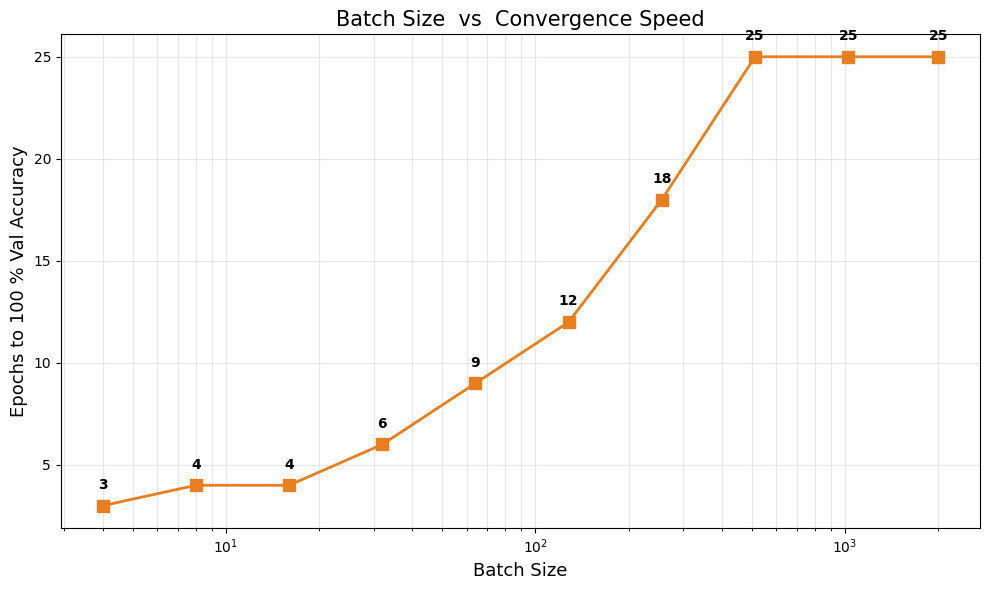


🎉  Done! Smaller batches = noisier gradients = more updates per epoch.
Larger batches are smoother but need more epochs to see the same number of updates.


In [ ]:
#@title visualize
fig, ax = plt.subplots(figsize=(10, 6))

bss    = list(bs_results.keys())
epochs = list(bs_results.values())

ax.plot(bss, epochs, "s-", markersize=9, linewidth=2, color="#e67e22")
ax.set_xscale("log")
ax.set_xlabel("Batch Size", fontsize=13)
ax.set_ylabel("Epochs to 100 % Val Accuracy", fontsize=13)
ax.set_title("Batch Size  vs  Convergence Speed", fontsize=15)
ax.grid(True, alpha=0.3, which="both")

for bs_val, ep in zip(bss, epochs):
    label = str(ep) if ep < 500 else "✗"
    ax.annotate(label, (bs_val, ep), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()
print("\n🎉  Done! Smaller batches = noisier gradients = more updates per epoch.")
print("Larger batches are smoother but need more epochs to see the same number of updates.")


# 7) Exercise: Best hidden dimensions

In [ ]:
hidden_configs = [
    (4, 2), (8, 4), (16, 8), (32, 16), (64, 32),
    (128, 64), (256, 128), (512, 256), (1024, 512), (2048, 1024)
]

assert False, "Loop over hidden config, send to epochs_to_converge and plot performance"

In [ ]:
#@title Answer
hd_results = {}
for h1, h2 in hidden_configs:
    ep = epochs_to_converge(lr=1e-3, hidden1=h1, hidden2=h2)

    params_count = (200 * h1 + h1) + (h1 * h2 + h2) + (h2 * 5 + 5)

    hd_results[params_count] = ep

    tag = f"{ep} epochs" if ep < 25 else "DID NOT CONVERGE"
    print(f"  Hidden {h1}/{h2} ({params_count} params) → {tag}")


Starting run with LR = 1e-03, bs=32, h1=4, h2=2
Epoch   1  │  Loss 1.6159  │  Train 20.2%  │  Val 19.6%
Epoch   2  │  Loss 1.6112  │  Train 23.6%  │  Val 21.7%
Epoch   3  │  Loss 1.6074  │  Train 28.1%  │  Val 25.7%
Epoch   4  │  Loss 1.6004  │  Train 29.1%  │  Val 26.7%
Epoch   5  │  Loss 1.5833  │  Train 27.6%  │  Val 28.3%
Epoch   6  │  Loss 1.5476  │  Train 32.9%  │  Val 33.2%
Epoch   7  │  Loss 1.5011  │  Train 33.4%  │  Val 33.7%
Epoch   8  │  Loss 1.4520  │  Train 32.5%  │  Val 32.0%
Epoch   9  │  Loss 1.4013  │  Train 32.4%  │  Val 31.6%
Epoch  10  │  Loss 1.3534  │  Train 36.4%  │  Val 37.2%
Epoch  11  │  Loss 1.3068  │  Train 38.5%  │  Val 40.5%
Epoch  12  │  Loss 1.2693  │  Train 39.5%  │  Val 41.3%
Epoch  13  │  Loss 1.2315  │  Train 43.0%  │  Val 45.0%
Epoch  14  │  Loss 1.1549  │  Train 52.4%  │  Val 52.9%
Epoch  15  │  Loss 1.1019  │  Train 54.5%  │  Val 55.4%
Epoch  16  │  Loss 1.0614  │  Train 57.5%  │  Val 58.3%
Epoch  17  │  Loss 1.0274  │  Train 58.3%  │  Val 59.3%

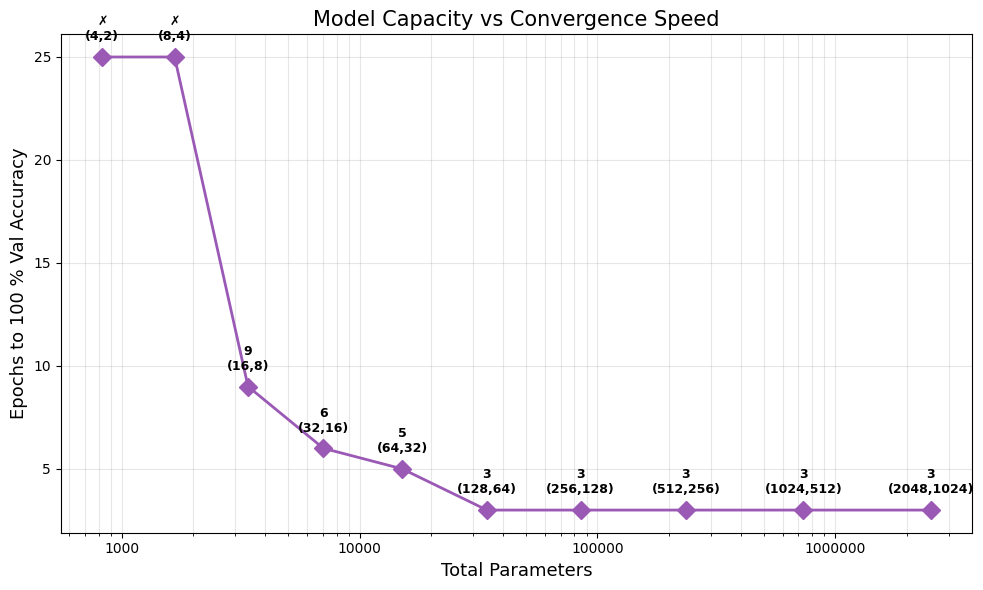

In [ ]:
#@title visualize hidden dimensions

# Plotting
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 6))

params = list(hd_results.keys())
epochs = list(hd_results.values())

ax.plot(params, epochs, "D-", markersize=9, linewidth=2, color="#9b59b6")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x):d}"))

ax.set_xlabel("Total Parameters", fontsize=13)
ax.set_ylabel("Epochs to 100 % Val Accuracy", fontsize=13)
ax.set_title("Model Capacity vs Convergence Speed", fontsize=15)
ax.grid(True, alpha=0.3, which="both")

for p_val, ep, (h1, h2) in zip(params, epochs, hidden_configs):
    label = f"{ep}\n({h1},{h2})" if ep < 25 else f"✗\n({h1},{h2})"
    ax.annotate(label, (p_val, ep), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


# 8) Exercise: Minimal training loop

In [ ]:
# code up a minimal training loop with the best LR and Batch Size
# no need for history or early breaking.
assert False, "did you code up the minimal training loop?"

AssertionError: did you code up the minimal training loop?

In [ ]:
#@title Answer - minimal training loop
best_lr = 1e-3
best_batch_size = 4
epochs = 25

model = Mod5MLP()
train_loader = DataLoader(train_dataset, batch_size=best_batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=best_batch_size)

optimizer = torch.optim.AdamW(model.parameters(), lr=best_lr)
criterion = nn.CrossEntropyLoss()

for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss = 0.0

    for x, y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    val_acc = calculate_accuracy(model, val_loader)
    print(f"Epoch {epoch} | Loss: {epoch_loss / len(train_loader):.4f} | Val Acc: {val_acc:.1%}")

    if val_acc == 1.0:
        print(f"\n✅ Perfect val accuracy reached at epoch {epoch}!")
        break

Epoch 1 | Loss: 1.6109 | Val Acc: 21.9%
Epoch 2 | Loss: 1.4301 | Val Acc: 77.6%
Epoch 3 | Loss: 0.2862 | Val Acc: 100.0%

✅ Perfect val accuracy reached at epoch 3!


# 9) What did we actually learn?

## 9.1) printing out the matrices

In [ ]:
# Set print options to show the full tensor without truncation
torch.set_printoptions(threshold=10_000, precision=1, sci_mode=False)

print("=== FULL NETWORK PARAMETER DIAGRAM ===\n")

for name, param in model.named_parameters():
    print(f"--- Layer: {name} | Shape: {list(param.shape)} ---")

    # Convert to numpy for clean formatting
    data = param.data.cpu().numpy()

    if len(data.shape) == 2:
        # It's a weight matrix
        for row_idx, row in enumerate(data):
            row_str = "  ".join([f"{val:5.1f}" for val in row])
            print(f"Row {row_idx:02d}: [ {row_str} ]")
    else:
        # It's a bias vector
        bias_str = "  ".join([f"{val:5.1f}" for val in data])
        print(f"Vector: [ {bias_str} ]")

    print("\n" + "="*50 + "\n")

=== FULL NETWORK PARAMETER DIAGRAM ===

--- Layer: net.0.weight | Shape: [32, 200] ---
Row 00: [  -0.2   -0.1    0.0   -0.1    0.2   -0.2   -0.0    0.1   -0.1    0.2   -0.2   -0.0   -0.2   -0.1    0.2   -0.2   -0.0   -0.2   -0.1    0.2   -0.2   -0.1   -0.1   -0.1    0.2   -0.2   -0.0    0.1   -0.1    0.2   -0.2   -0.0    0.1   -0.1    0.2   -0.2   -0.0   -0.2   -0.1    0.2   -0.2   -0.0   -0.0   -0.0    0.2   -0.2   -0.0   -0.2    0.2    0.2   -0.2   -0.0    0.1   -0.1    0.2   -0.2   -0.0   -0.2   -0.1    0.2   -0.2   -0.0   -0.1   -0.1    0.2   -0.2   -0.0    0.1   -0.1    0.2   -0.2   -0.0   -0.2   -0.0    0.2   -0.2   -0.0   -0.2   -0.1    0.2   -0.2   -0.0    0.1    0.0    0.2   -0.2   -0.0    0.1   -0.1    0.2   -0.2   -0.0    0.1   -0.1    0.2   -0.2    0.0    0.1   -0.1    0.2   -0.1    0.1   -0.2    0.1    0.2   -0.2    0.1   -0.2    0.1   -0.0   -0.2    0.1   -0.2    0.0    0.2   -0.2    0.1   -0.1    0.0    0.2   -0.2    0.1   -0.2    0.1    0.2   -0.2    0.1   -0.2    0.0  

## 9.2) Visualizing weight distribution

Looks like there's a repeating pattern in Weight1?

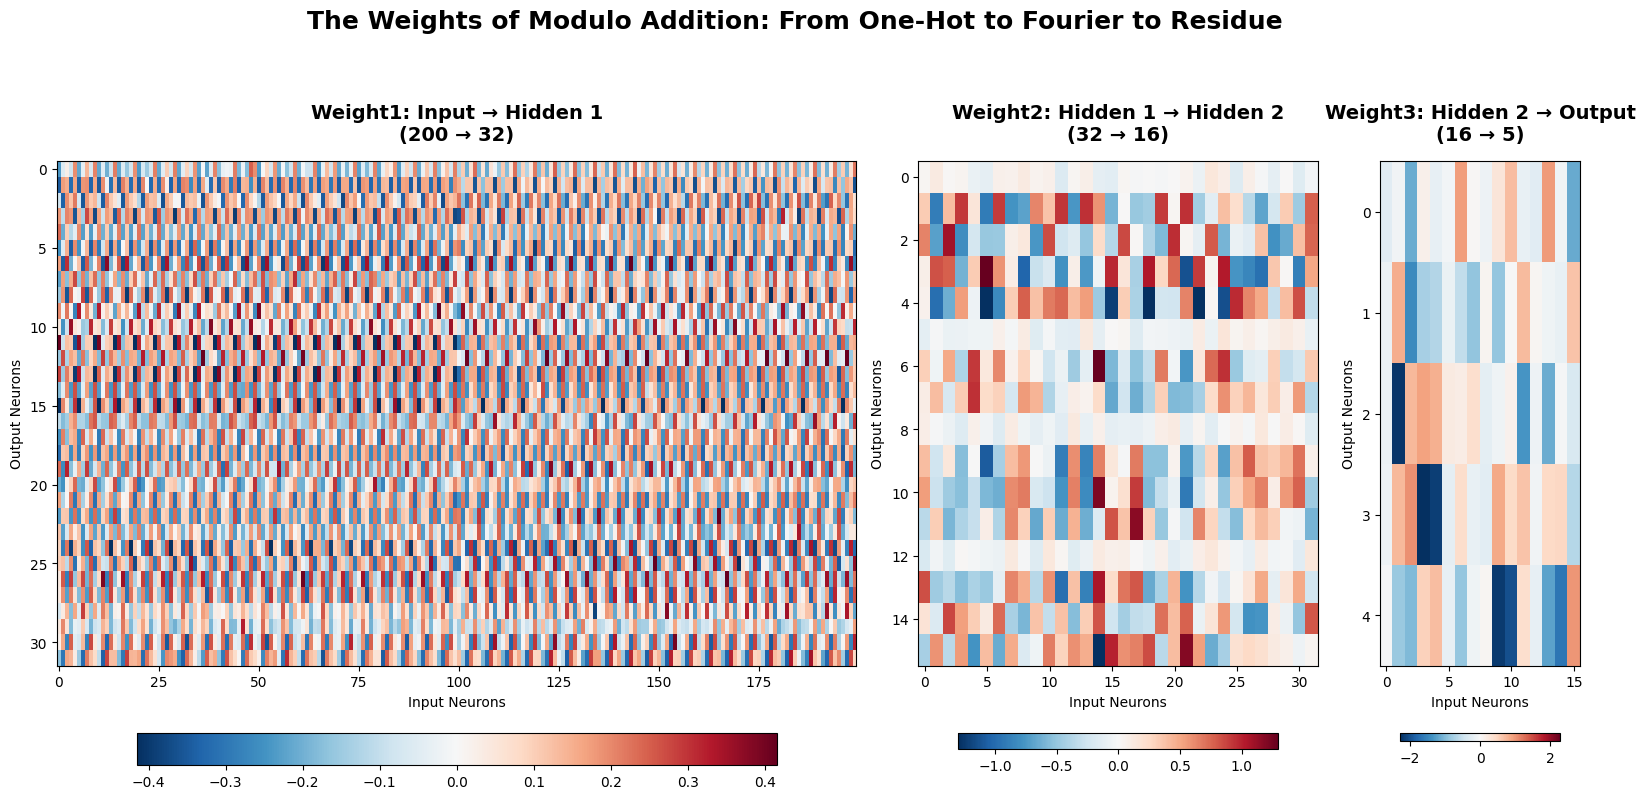

In [ ]:
#@title Visualization

# Extract weights from all layers
weights = []
for layer in model.net:
    if isinstance(layer, nn.Linear):
        weights.append(layer.weight.data.cpu().numpy())

fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(1, 3, width_ratios=[4, 2, 1])

# Helper for labels
layer_names = ["Weight1: Input → Hidden 1\n(200 → 32)",
               "Weight2: Hidden 1 → Hidden 2\n(32 → 16)",
               "Weight3: Hidden 2 → Output\n(16 → 5)"]

for i, (w, name) in enumerate(zip(weights, layer_names)):
    ax = fig.add_subplot(gs[i])

    # Use a diverging colormap to highlight positive/negative weights
    vmax = np.percentile(np.abs(w), 99)
    im = ax.imshow(w, cmap="RdBu_r", aspect="auto", vmin=-vmax, vmax=vmax)

    ax.set_title(name, fontsize=14, fontweight="bold", pad=15)
    ax.set_ylabel("Output Neurons", fontsize=10)
    ax.set_xlabel("Input Neurons", fontsize=10)

    # Add colorbar for each
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.1, shrink=0.8)

plt.suptitle("The Weights of Modulo Addition: From One-Hot to Fourier to Residue",
             fontsize=18, fontweight="bold", y=1.05)

plt.tight_layout()
plt.show()

## 9.3.) PCA for Weight1 layer

What happens when we reduce the dimensionality to 2D?

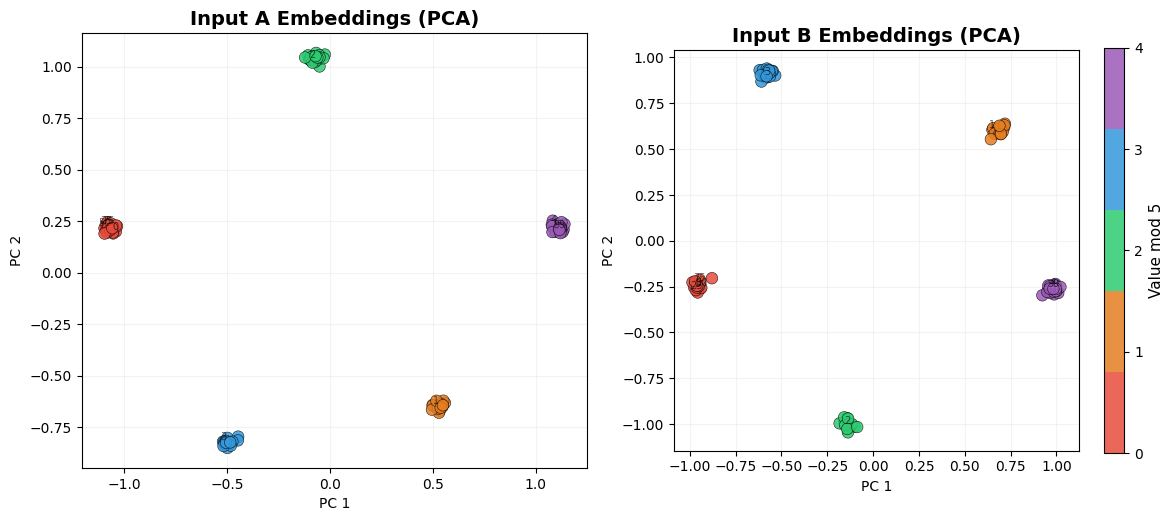

In [ ]:
from sklearn.decomposition import PCA

# Split into the A-input and B-input halves
w1 = model.net[0].weight.data.cpu().numpy()
w1_A = w1[:, :100]   # weights connecting to the 100-dim one-hot for A
w1_B = w1[:, 100:]   # weights connecting to the 100-dim one-hot for B


# Transpose so each of the 100 input numbers is a row
w1_A_T = w1_A.T  # shape (100, hidden)
w1_B_T = w1_B.T

pca_A = PCA(n_components=2).fit_transform(w1_A_T)
pca_B = PCA(n_components=2).fit_transform(w1_B_T)

colors_mod5 = np.arange(100) % 5
palette = ["#e74c3c", "#e67e22", "#2ecc71", "#3498db", "#9b59b6"]
cmap_5 = mcolors.ListedColormap(palette)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

for ax, proj, label in [(ax1, pca_A, "Input A"), (ax2, pca_B, "Input B")]:
    sc = ax.scatter(proj[:, 0], proj[:, 1],
                    c=colors_mod5, cmap=cmap_5, s=70, alpha=0.85,
                    edgecolors="k", linewidths=0.4)
    ax.set_title(f"{label} Embeddings (PCA)", fontsize=14, fontweight="bold")
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.15)

    # Label a few representative numbers
    for num in [0, 1, 2, 3, 4, 25, 50, 75, 99]:
        ax.annotate(str(num), (proj[num, 0], proj[num, 1]),
                    fontsize=7, ha="center", va="bottom", alpha=0.6)

cbar = plt.colorbar(sc, ax=ax2, ticks=[0, 1, 2, 3, 4], shrink=0.8)
cbar.set_label("Value mod 5", fontsize=11)

plt.tight_layout()
plt.show()